<a href="https://colab.research.google.com/github/RCalvoso/grupo4_projeto_integrador_2/blob/main/03_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✅ Arquivos de treino/validação/teste encontrados em: /content/drive/MyDrive/Especialização em Inteligência Artificial PUC-SP 2026/Módulo 2/Projeto Integrador II -Aplicação de Deep Learning/dataset

Dimensão da matriz tabular: 57 atributos.
Classes ativas: 6 (['Acesso' 'Financeiro' 'Hardware' 'RH' 'Rede' 'Software'])

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2277 - loss: 2.0436 - val_accuracy: 0.3427 - val_loss: 1.6596
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3091 - loss: 1.7152 - val_accuracy: 0.3493 - val_loss: 1.5754
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3420 - loss: 1.6247 - val_accuracy: 0.3680 - val_loss: 1.5203
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3886 - loss: 1.5403 - val_accuracy: 0.3880 - val_loss: 1.4894
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4031 - loss: 1.4880 - val_accuracy: 0.4093 - val_loss: 1.4587
Epoch 6/5

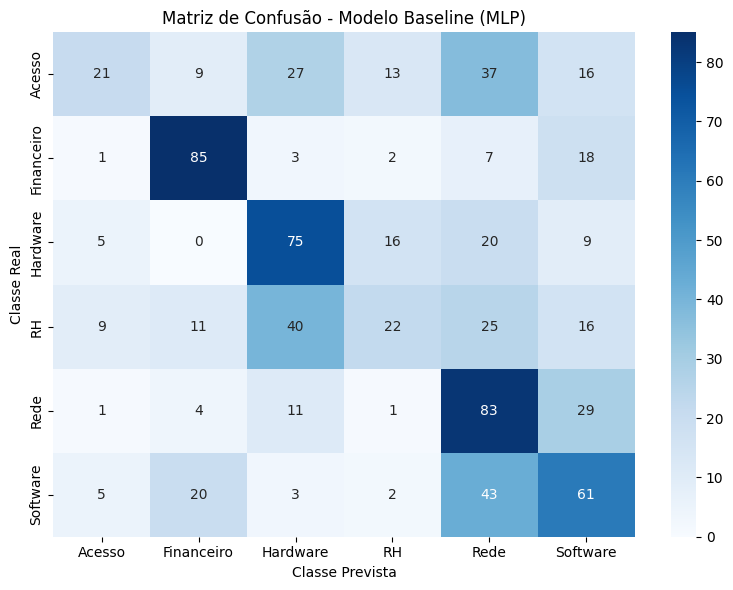

In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Garantir que o Drive está montado
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Localizar a pasta onde os arquivos 'train_clean.csv' foram salvos
dir_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'train_clean.csv' in files:
        dir_path = root
        break

if dir_path:
    print(f"✅ Arquivos de treino/validação/teste encontrados em: {dir_path}\n")

    # 3. Carregar os datasets limpos
    train_df = pd.read_csv(os.path.join(dir_path, 'train_clean.csv'))
    val_df = pd.read_csv(os.path.join(dir_path, 'val_clean.csv'))
    test_df = pd.read_csv(os.path.join(dir_path, 'test_clean.csv'))

    # 4. Selecionar atributos estruturados e target
    ignored_cols = ['ticket_id', 'title', 'description', 'image_path', 'target_category', 'created_at', 'updated_at']
    feature_cols = [c for c in train_df.columns if c not in ignored_cols]

    X_train = train_df[feature_cols]
    y_train = train_df['target_category']

    X_val = val_df[feature_cols]
    y_val = val_df['target_category']

    X_test = test_df[feature_cols]
    y_test = test_df['target_category']

    # 5. Pré-processamento dos dados estruturados
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    # Encoding do alvo
    classes = np.unique(y_train)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_train_enc = np.array([class_to_idx[c] for c in y_train])
    y_val_enc = np.array([class_to_idx[c] for c in y_val])
    y_test_enc = np.array([class_to_idx[c] for c in y_test])

    print(f"Dimensão da matriz tabular: {X_train_proc.shape[1]} atributos.")
    print(f"Classes ativas: {len(classes)} ({classes})\n")

    # 6. Construção do Modelo Baseline MLP
    model = models.Sequential([
        layers.Input(shape=(X_train_proc.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(len(classes), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # 7. Treinamento
    history = model.fit(
        X_train_proc, y_train_enc,
        validation_data=(X_val_proc, y_val_enc),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # 8. Avaliação de Teste
    test_loss, test_acc = model.evaluate(X_test_proc, y_test_enc, verbose=0)
    y_pred_probs = model.predict(X_test_proc)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\n=== RESULTADOS BASELINE (MLP Estruturado) ===")
    print(f"Acurácia no Teste: {test_acc:.4f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test_enc, y_pred, target_names=classes))

    # 9. Matriz de Confusão
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test_enc, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Matriz de Confusão - Modelo Baseline (MLP)')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.tight_layout()
    plt.show()

else:
    print("❌ Arquivo train_clean.csv não encontrado. Execute primeiro o notebook 02_Engenharia_Dados.ipynb!")